In [17]:
import pandas as pd 
data = pd.read_csv('ec2dataset.csv')

In [18]:
cost_columns = ['On Demand', 'Linux Reserved cost', 'Linux Spot Minimum cost', 'Windows On Demand cost', 'Windows Reserved cost']
for column in cost_columns:
    data[column] = pd.to_numeric(data[column].astype(str).str.replace(r'[$,]|hourly', '', regex=True).str.strip(), errors='coerce')


In [19]:
# Convert memory from string (e.g., '0.5 GiB') to numeric by stripping ' GiB'
data['Instance Memory'] = pd.to_numeric(data['Instance Memory'].str.replace(' GiB', ''))
# Extract the number of vCPUs from the 'vCPUs' column (e.g., '2 vCPUs')
data['vCPUs'] = pd.to_numeric(data['vCPUs'].str.extract(r'(\d+)', expand=False))
# Check the data after conversion
print(data[['Instance Memory', 'vCPUs']].head())


   Instance Memory  vCPUs
0              0.5      2
1              0.5      2
2              0.5      2
3              0.5      1
4              1.0      2


In [20]:
# Drop rows with missing values in the relevant columns (for simplicity)
data_cleaned = data.dropna(subset=['On Demand', 'Instance Memory', 'vCPUs'])

# Remove outliers using the IQR rule: keep values within 1.5 * IQR of the middle 50%
outlier_columns = ['On Demand', 'Instance Memory', 'vCPUs']
mask = pd.Series(True, index=data_cleaned.index)
for column in outlier_columns:
    q1 = data_cleaned[column].quantile(0.25)
    q3 = data_cleaned[column].quantile(0.75)
    iqr = q3 - q1
    mask &= data_cleaned[column].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
print(f"Removed {(~mask).sum()} outliers out of {len(data_cleaned)} rows")
data_cleaned = data_cleaned[mask]

# Verify that the cleaned data has no missing values
print(data_cleaned.isnull().sum())


Removed 94 outliers out of 841 rows
Name                         0
API Name                     0
Instance Memory              0
vCPUs                        0
Instance Storage             0
Network Performance          0
On Demand                    0
Linux Reserved cost          3
Linux Spot Minimum cost      7
Windows On Demand cost     222
Windows Reserved cost      225
dtype: int64


In [21]:
from sklearn.model_selection import train_test_split
# Define features and target
X = data_cleaned[['Instance Memory', 'vCPUs']]
y = data_cleaned['On Demand']
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")


Training samples: 597, Testing samples: 150


In [22]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer

# Log-log linear regression: fit log(cost) = b0 + b1*log(memory) + b2*log(vCPUs)
# Prices grow by multiples, so a straight line on the log scale fits much better and
# never predicts a negative cost. model.predict() still returns dollars.
model = TransformedTargetRegressor(
    regressor=make_pipeline(FunctionTransformer(np.log, feature_names_out='one-to-one'), LinearRegression()),
    func=np.log,
    inverse_func=np.exp,
)
model.fit(X_train, y_train)
# Print the coefficients of the model (on the log scale)
linear = model.regressor_[-1]
print(f"Intercept: {linear.intercept_}")
print(f"Coefficients: {linear.coef_}")


Intercept: -3.6908897869934543
Coefficients: [0.56422694 0.4538438 ]


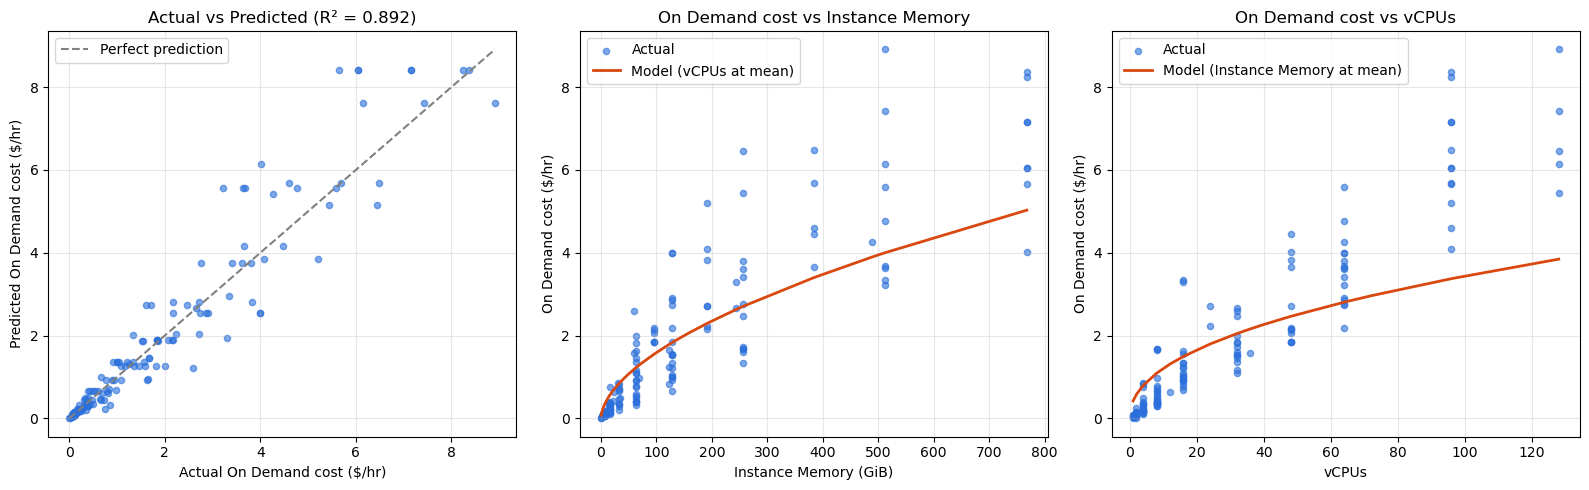

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Predict on the test set
y_pred = model.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Actual vs predicted: points on the dashed line = perfect predictions
ax = axes[0]
ax.scatter(y_test, y_pred, s=20, alpha=0.6, color='#2a6fdb')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, '--', color='gray', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual On Demand cost ($/hr)')
ax.set_ylabel('Predicted On Demand cost ($/hr)')
ax.set_title(f'Actual vs Predicted (R² = {r2_score(y_test, y_pred):.3f})')
ax.legend()

# 2 & 3) Cost vs each feature, with the model's line holding the other feature at its mean
for ax, feature in zip(axes[1:], ['Instance Memory', 'vCPUs']):
    other = 'vCPUs' if feature == 'Instance Memory' else 'Instance Memory'
    ax.scatter(X_test[feature], y_test, s=20, alpha=0.6, color='#2a6fdb', label='Actual')
    x_line = pd.DataFrame({feature: sorted(X[feature].unique())})
    x_line[other] = X_train[other].mean()
    ax.plot(x_line[feature], model.predict(x_line[X.columns]), color='#d9480f', linewidth=2,
            label=f'Model ({other} at mean)')
    ax.set_xlabel('Instance Memory (GiB)' if feature == 'Instance Memory' else 'vCPUs')
    ax.set_ylabel('On Demand cost ($/hr)')
    ax.set_title(f'On Demand cost vs {feature}')
    ax.legend()

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Predict the costs for the test data
y_pred = model.predict(X_test)
# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")


Mean Absolute Error (MAE): 0.38259496440597834
Mean Squared Error (MSE): 0.46512483174532765
Root Mean Squared Error (RMSE): 0.6820006097836919


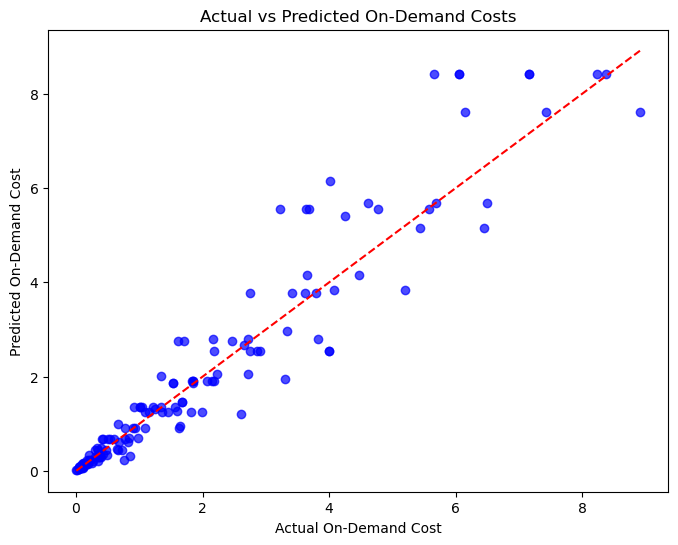

In [25]:
import matplotlib.pyplot as plt
# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='b')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Actual vs Predicted On-Demand Costs')
plt.xlabel('Actual On-Demand Cost')
plt.ylabel('Predicted On-Demand Cost')
plt.show()


In [26]:
# Example: Predict cost for a new instance with 4 GiB memory and 2 vCPUs
new_instance = pd.DataFrame([[4, 2]], columns=['Instance Memory', 'vCPUs'])
predicted_cost = model.predict(new_instance)
print(f"Predicted On-Demand Cost for 4 GiB, 2 vCPUs: ${predicted_cost[0]:.4f}")


Predicted On-Demand Cost for 4 GiB, 2 vCPUs: $0.0747


In [27]:
import pickle

with open('modelEC2.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved to model.pkl")

Model saved to model.pkl
